# Customer Segmentation
#### Goal: To analyze customer data and group customers into meaningful clusters based on similarities in their purchasing behavior and demographics, using clustering algorithms such as K-Means,hierarchial clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Path to dataset files:", path)

100%|██████████| 1.56k/1.56k [00:00<00:00, 1.94MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shwetabh123/mall-customers/versions/1


In [3]:
df = pd.read_csv(f"{path}/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
import os

# List contents of the path directory
print(os.listdir(path))

['Mall_Customers.csv']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.dtypes

,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [7]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df.nunique()

,0
CustomerID,200
Genre,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [9]:
df = pd.get_dummies(df, columns=['Genre'], drop_first=True, dtype=int)

In [10]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [11]:
df.rename(columns={'Genre_Male': 'Gender'}, inplace=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [12]:
# Select only the relevant numerical features for clustering
features_for_clustering = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']
X = df[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992, -0.88640526],
       [-1.20926872, -1.66266033,  1.00159627, -0.88640526],
       [-0.27630176, -1.62449091, -1.71591298, -0.88640526],
       [-1.13750203, -1.62449091,  1.70038436, -0.88640526],
       [ 1.80493225, -1.58632148, -1.83237767,  1.12815215],
       [-0.6351352 , -1.58632148,  0.84631002, -0.88640526],
       [ 2.02023231, -1.58632148, -1.4053405 ,  1.12815215],
       [-0.27630176, -1.58632148,  1.89449216, -0.88640526],
       [ 1.37433211, -1.54815205, -1.36651894, -0.88640526],
       [-1.06573534, -1.54815205,  1.04041783, -0.88640526],
       [-0.13276838, -1.54815205, -1.44416206,  1.12815215],
       [-1.20926872, -1.54815205,  1.11806095,  1.12815215],
       [-0.27630176, -1.

## Hyperparameter Tuning

In [14]:
inertia =[]
for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

In [15]:
inertia

[800.0000000000003,
 597.9472937932284,
 494.8037500130456,
 395.3920903479796,
 351.7432061711911,
 277.3897401985192,
 251.15484911190165,
 211.98576294959312,
 185.72807688711433,
 152.02983429775693]

## Draw the elbow plot

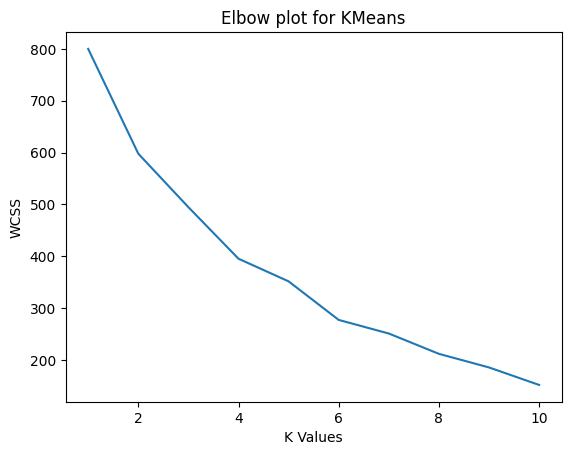

In [16]:
plt.plot(range(1,11),inertia)
plt.title("Elbow plot for KMeans")
plt.xlabel('K Values')
plt.ylabel('WCSS')
plt.show()

In [17]:
kmeans_model = KMeans(n_clusters=5, random_state=42)
kmeans_model.fit(X_scaled)
df['KMeans_Cluster'] = kmeans_model.labels_
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender,KMeans_Cluster
0,1,19,15,39,1,2
1,2,21,15,81,1,2
2,3,20,16,6,0,4
3,4,23,16,77,0,4
4,5,31,17,40,0,4


In [18]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,51
3,49
2,42
4,38
1,20


In [19]:
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

param_grid = {"n_clusters": [2, 3, 4, 5, 6], "init": ["k-means++", "random"]}

grid = GridSearchCV(
    KMeans(random_state=42, n_init=10),
    param_grid,
    scoring=silhouette_scorer,
    cv=5
)
grid.fit(X_scaled)
print("Best params:", grid.best_params_)

Best params: {'init': 'random', 'n_clusters': 4}


In [20]:
kmeans_final_model = KMeans(n_clusters=4, init='random', random_state=42)
kmeans_final_model.fit(X_scaled)
df['KMeans_Cluster'] = kmeans_model.labels_
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender,KMeans_Cluster
0,1,19,15,39,1,2
1,2,21,15,81,1,2
2,3,20,16,6,0,4
3,4,23,16,77,0,4
4,5,31,17,40,0,4


In [21]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,51
3,49
2,42
4,38
1,20


### Hierarchical Clustering

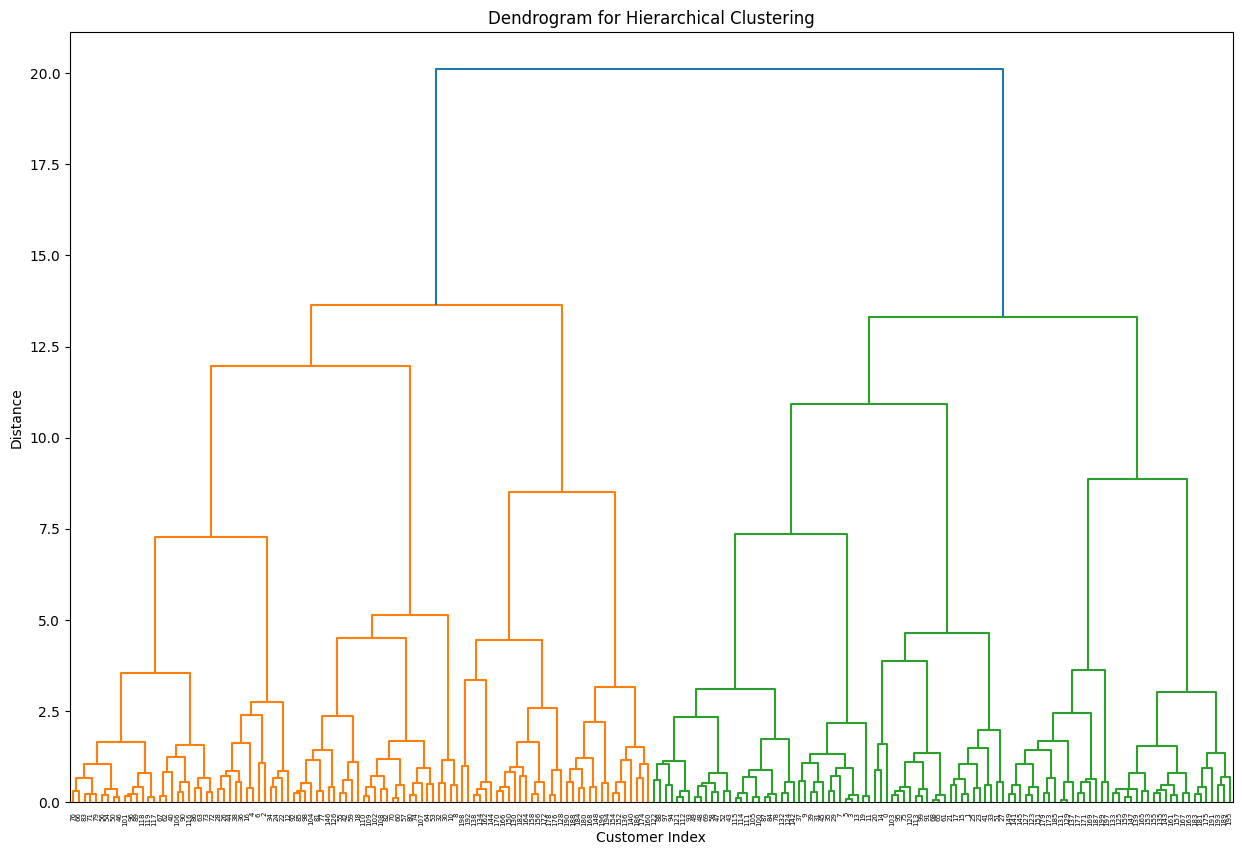

In [27]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create a linkage matrix for plotting the dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()

In [22]:
hc_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['HC_Cluster'] = hc_model.fit_predict(X_scaled)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender,KMeans_Cluster,HC_Cluster
0,1,19,15,39,1,2,0
1,2,21,15,81,1,2,0
2,3,20,16,6,0,4,3
3,4,23,16,77,0,4,0
4,5,31,17,40,0,4,3


In [28]:
# GridSearchCV for AgglomerativeClustering
param_grid_hc = {"n_clusters": [2, 3, 4, 5, 6], "linkage": ['ward', 'complete', 'average', 'single']}

grid_hc = GridSearchCV(
    AgglomerativeClustering(),
    param_grid_hc,
    scoring=silhouette_scorer,
    cv=5
)
grid_hc.fit(X_scaled)
print("Best params for Hierarchical Clustering:", grid_hc.best_params_)

Best params for Hierarchical Clustering: {'linkage': 'ward', 'n_clusters': 4}


In [29]:
hc_final_model = AgglomerativeClustering(n_clusters= 4,
                                         linkage='ward')
df['HC_Cluster'] = hc_final_model.fit_predict(X_scaled)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender,KMeans_Cluster,HC_Cluster
0,1,19,15,39,1,2,1
1,2,21,15,81,1,2,1
2,3,20,16,6,0,4,0
3,4,23,16,77,0,4,1
4,5,31,17,40,0,4,0


In [30]:
df['HC_Cluster'].value_counts()

,count
HC_Cluster,
0,67
1,61
3,39
2,33


### Model Comparison

Now that we have cluster assignments from both K-Means and Hierarchical Clustering, let's compare them. We can visualize the clusters and also use metrics like Silhouette Score to evaluate the quality of the clustering for each model. We will primarily compare the clustering using scatter plots of two important features, for example, 'Annual Income (k$)' and 'Spending Score (1-100)', colored by their respective cluster labels.

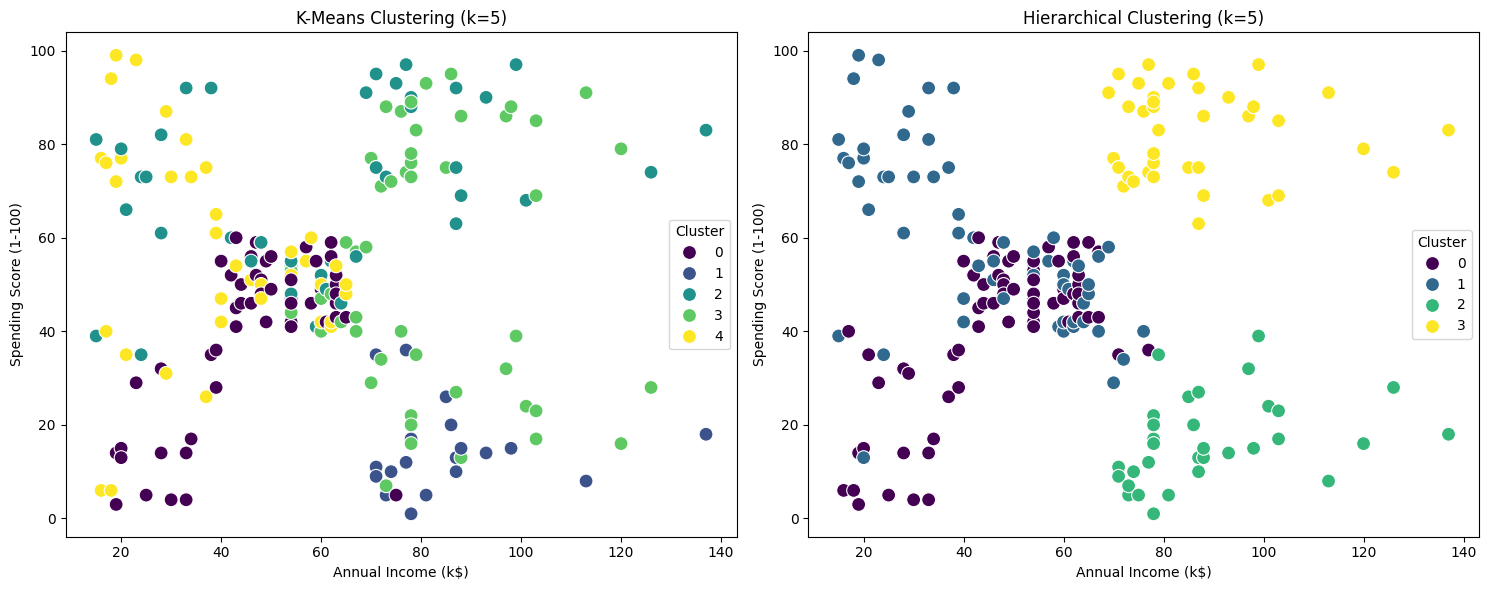

In [35]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=df, palette='viridis',s=100)
plt.title('K-Means Clustering (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='HC_Cluster', data=df, palette='viridis', s=100)
plt.title('Hierarchical Clustering (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [38]:
# Evaluate clustering with Silhouette Score
silhouette_kmeans = silhouette_score(X_scaled, df['KMeans_Cluster'])
silhouette_hc = silhouette_score(X_scaled, df['HC_Cluster'])

print(f"Silhouette Score for K-Means Clustering: {silhouette_kmeans:.3f}")
print(f"Silhouette Score for Hierarchical Clustering: {silhouette_hc:.3f}")

Silhouette Score for K-Means Clustering: 0.272
Silhouette Score for Hierarchical Clustering: 0.263


## Conclusion

Based on the analysis, both K-Means and Hierarchical Clustering were applied to segment the customers. The dataset was preprocessed by one-hot encoding the 'Genre' feature and scaling all numerical features.

### Model Comparison
Comparing the two models based on their best configurations:
- K-Means with 4 clusters achieved a slightly higher Silhouette Score (0.272) compared to Hierarchical Clustering with 4 clusters (0.263). This suggests that K-Means produced a marginally better-defined clustering structure according to this metric for this dataset.

